In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings("ignore")

df=pd.read_csv('/content/co2_monthly_1987_2026_clean.csv')


monthly = df.groupby(['Year','Month'])['Total_CO2'].sum().reset_index()

# Build a proper datetime index — essential for SARIMA
ts = monthly.copy()
ts['date'] = pd.to_datetime(ts[['Year','Month']].assign(DAY=1))
ts = ts.set_index('date')['Total_CO2'].asfreq('MS')  # monthly start
print(ts.head())
print("Length:", len(ts))

date
1987-01-01    4113.08
1987-02-01    3727.06
1987-03-01    4048.62
1987-04-01    4034.86
1987-05-01    4789.66
Freq: MS, Name: Total_CO2, dtype: float64
Length: 471


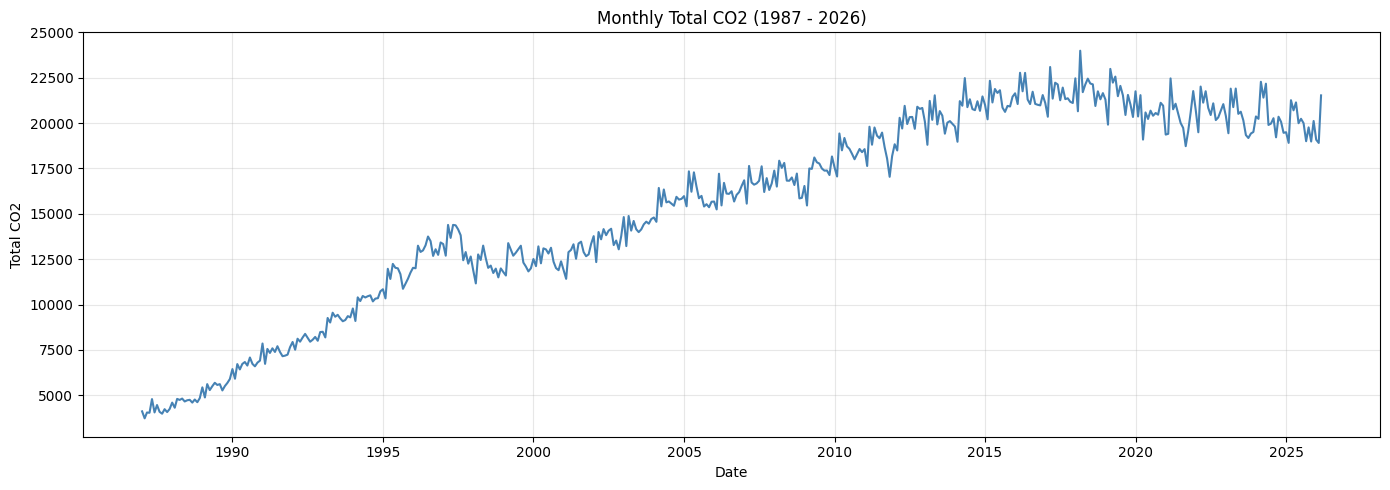

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ts.index, ts.values, color='steelblue')
ax.set_title('Monthly Total CO2 (1987 - 2026)')
ax.set_ylabel('Total CO2')
ax.set_xlabel('Date')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

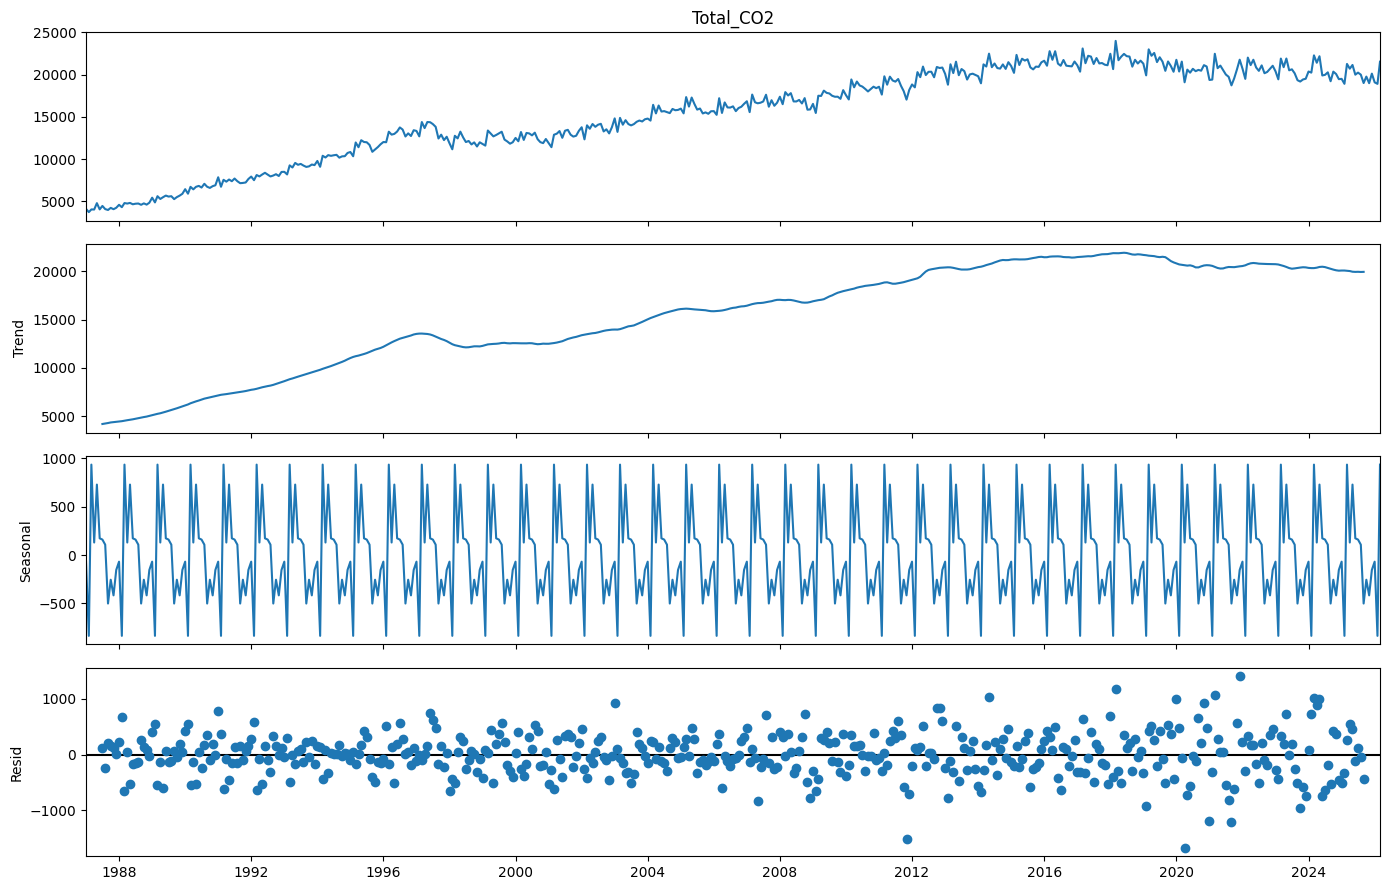

In [ ]:
decomp = seasonal_decompose(ts, model='additive', period=12)
ax.set_ylabel('Total CO2')
ax.set_xlabel('Date')
fig = decomp.plot()
fig.set_size_inches(14, 9)
plt.tight_layout()
plt.show()

In [ ]:
def adf_test(series, name=""):
    result = adfuller(series.dropna())
    print(f"ADF Test — {name}")
    print(f"  Statistic : {result[0]:.4f}")
    print(f"  p-value   : {result[1]:.4f}")
    print(f"  → {'Stationary' if result[1] < 0.05 else 'Non-stationary'}")

def kpss_test(series, name="", regression='c'):
    stat, p, _, _ = kpss(series.dropna(), regression=regression, nlags='auto')
    print(f"KPSS Test — {name}  (regression='{regression}')")
    print(f"  Statistic : {stat:.4f}")
    print(f"  p-value   : {p:.4f}")
    print(f"  → {'Stationary' if p > 0.05 else 'Non-stationary'}")

# Raw series: use regression='ct' because the series has a visible upward trend
adf_test(ts, "raw")
print()
kpss_test(ts, "raw", regression='ct')

ADF Test — raw
  Statistic : -2.4501
  p-value   : 0.1281
  → Non-stationary

KPSS Test — raw  (regression='ct')
  Statistic : 0.6140
  p-value   : 0.0100
  → Non-stationary


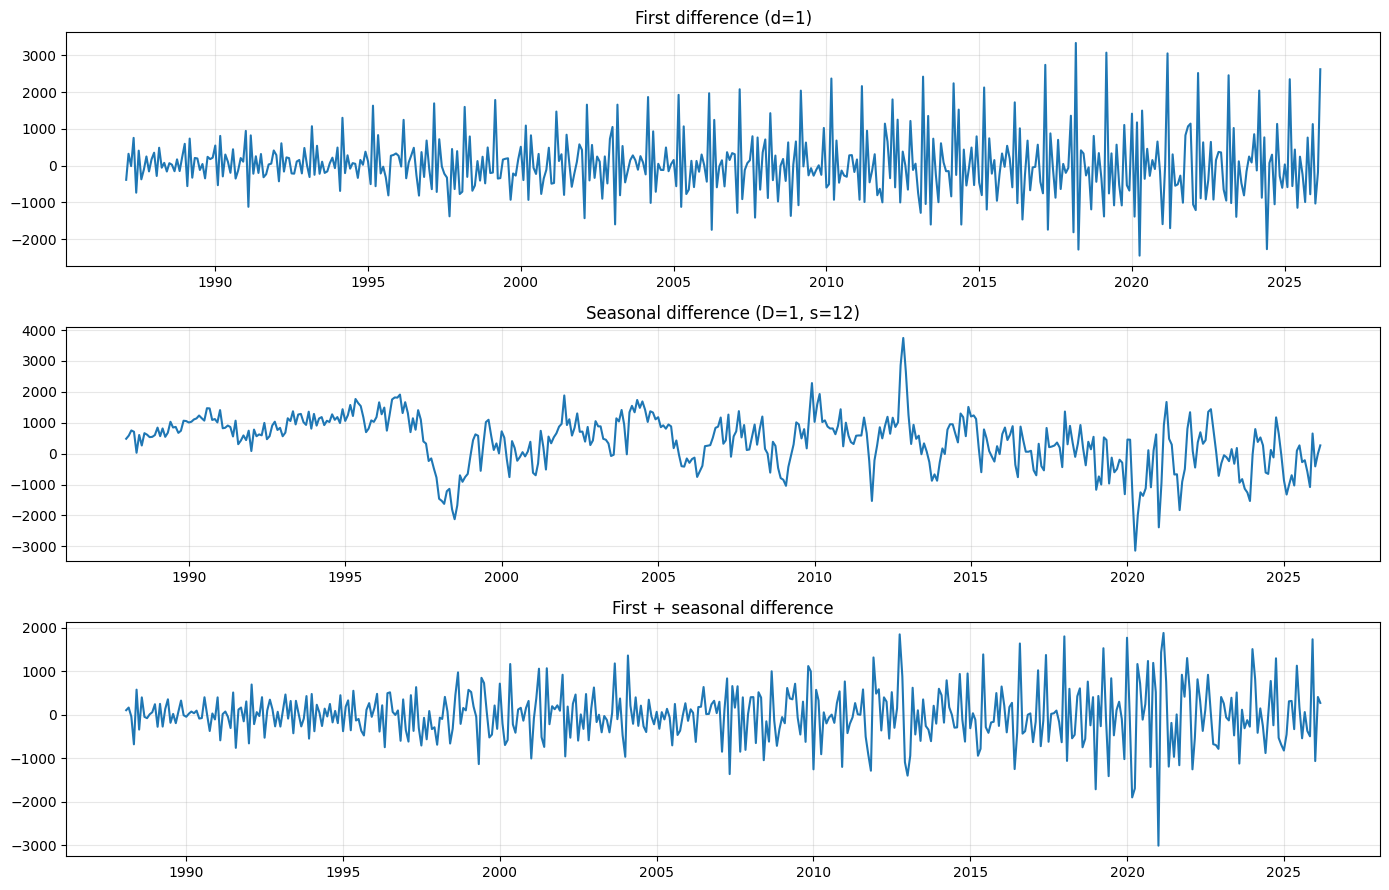


--- After first difference ---
ADF Test — d=1
  Statistic : -4.0075
  p-value   : 0.0014
  → Stationary
KPSS Test — d=1  (regression='c')
  Statistic : 0.2605
  p-value   : 0.1000
  → Stationary

--- After first + seasonal difference ---
ADF Test — d=1, D=1
  Statistic : -8.9519
  p-value   : 0.0000
  → Stationary
KPSS Test — d=1, D=1  (regression='c')
  Statistic : 0.0453
  p-value   : 0.1000
  → Stationary


In [ ]:
ts_diff = ts.diff().dropna()                  # d=1
ts_seasonal_diff = ts.diff(12).dropna()       # D=1, seasonal
ts_both = ts.diff().diff(12).dropna()         # d=1 AND D=1

fig, axes = plt.subplots(3, 1, figsize=(14, 9))
axes[0].plot(ts_diff);          axes[0].set_title('First difference (d=1)')
axes[1].plot(ts_seasonal_diff); axes[1].set_title('Seasonal difference (D=1, s=12)')
axes[2].plot(ts_both);          axes[2].set_title('First + seasonal difference')
for ax in axes: ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n--- After first difference ---")
adf_test(ts_diff, "d=1")
kpss_test(ts_diff, "d=1")

print("\n--- After first + seasonal difference ---")
adf_test(ts_both, "d=1, D=1")
kpss_test(ts_both, "d=1, D=1")

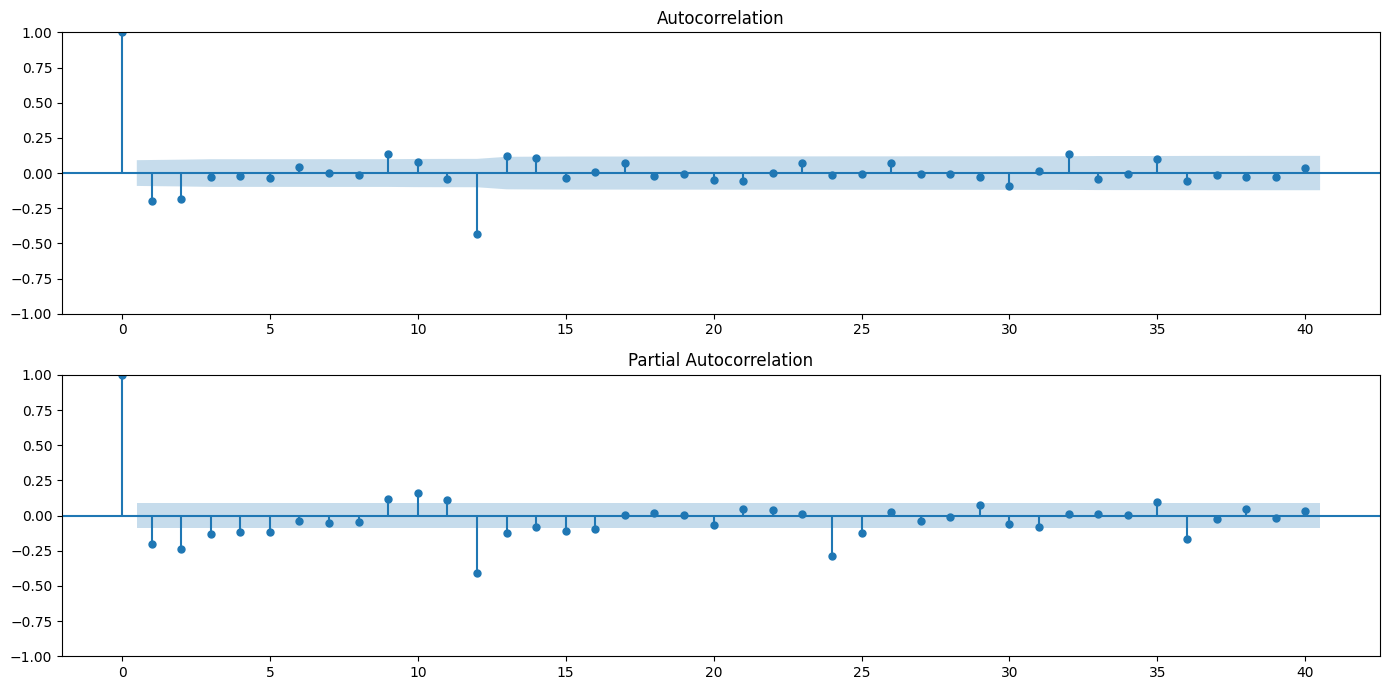

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))
plot_acf(ts_both,  lags=40, ax=axes[0])
plot_pacf(ts_both, lags=40, ax=axes[1], method='ywm')
plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

train = ts[:'2023-12-01']   # consistent with LR, XGBoost, Prophet — all before Jan 2024
test  = ts['2024-01-01':]
# Starting point — adjust (p,d,q)(P,D,Q,s) based on ACF/PACF and tests
model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
result = model.fit(disp=False)
print(result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                          Total_CO2   No. Observations:                  444
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -3135.174
Date:                            Sat, 06 Jun 2026   AIC                           6280.348
Time:                                    11:20:18   BIC                           6300.514
Sample:                                01-01-1987   HQIC                          6288.321
                                     - 12-01-2023                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2849      0.083      3.420      0.001       0.122       0.448
ma.L1         -0.6784      0.067   

MAE  : 699.42
RMSE : 841.74
MAPE : 3.40%


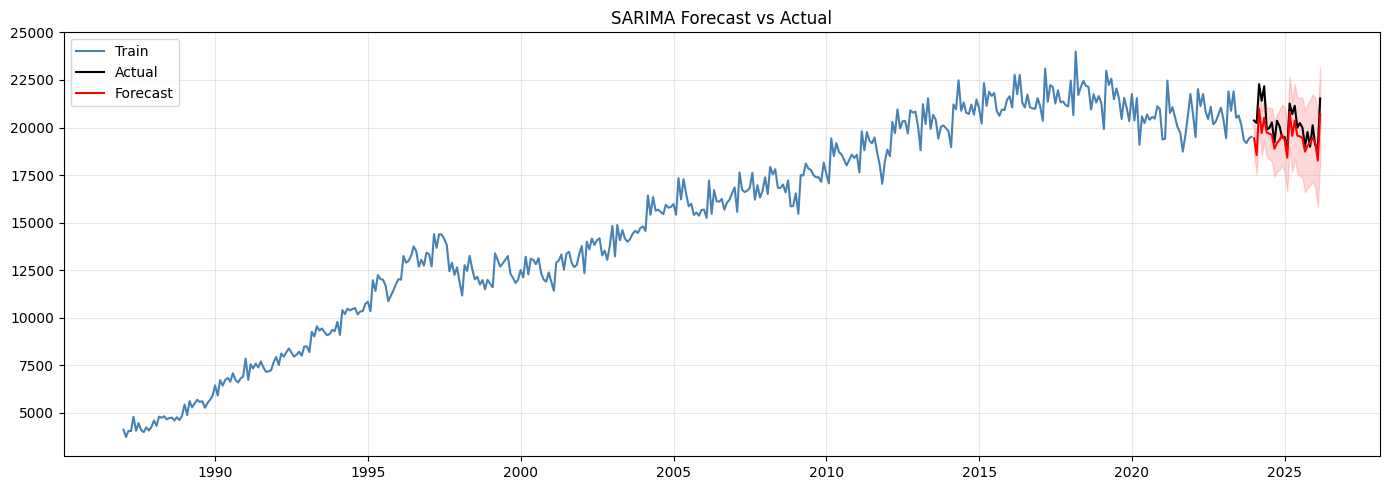

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

forecast = result.get_forecast(steps=len(test))
pred_mean = forecast.predicted_mean
pred_ci   = forecast.conf_int()

mae  = mean_absolute_error(test, pred_mean)
rmse = np.sqrt(mean_squared_error(test, pred_mean))
mape = np.mean(np.abs((test - pred_mean) / test)) * 100
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index, train, label='Train', color='steelblue')
ax.plot(test.index, test, label='Actual', color='black')
ax.plot(pred_mean.index, pred_mean, label='Forecast', color='red')
ax.fill_between(pred_ci.index, pred_ci.iloc[:,0], pred_ci.iloc[:,1], color='red', alpha=0.15)
ax.set_title('SARIMA Forecast vs Actual')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

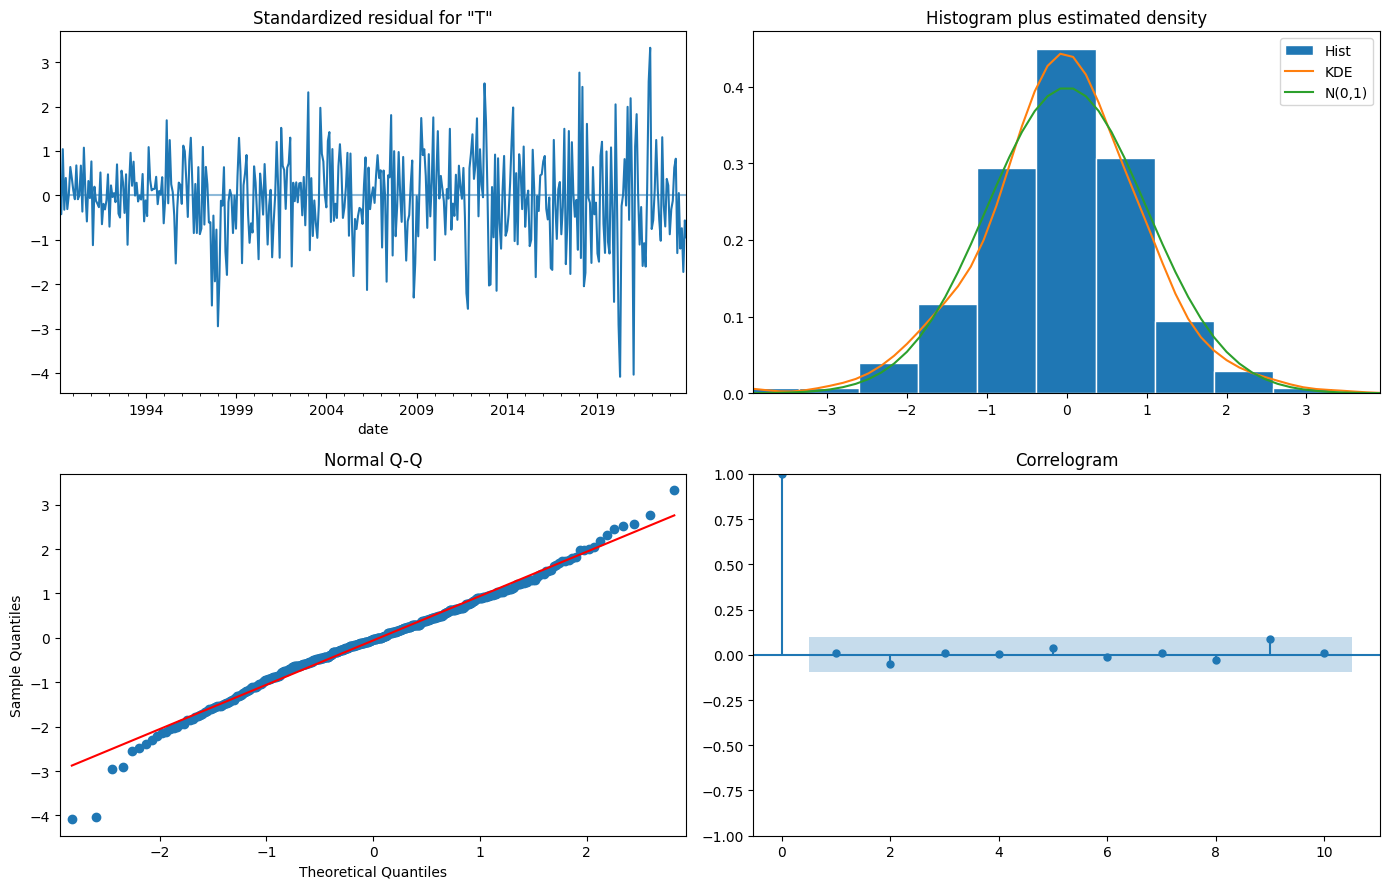

In [ ]:
result.plot_diagnostics(figsize=(14, 9))
plt.tight_layout()
plt.show()

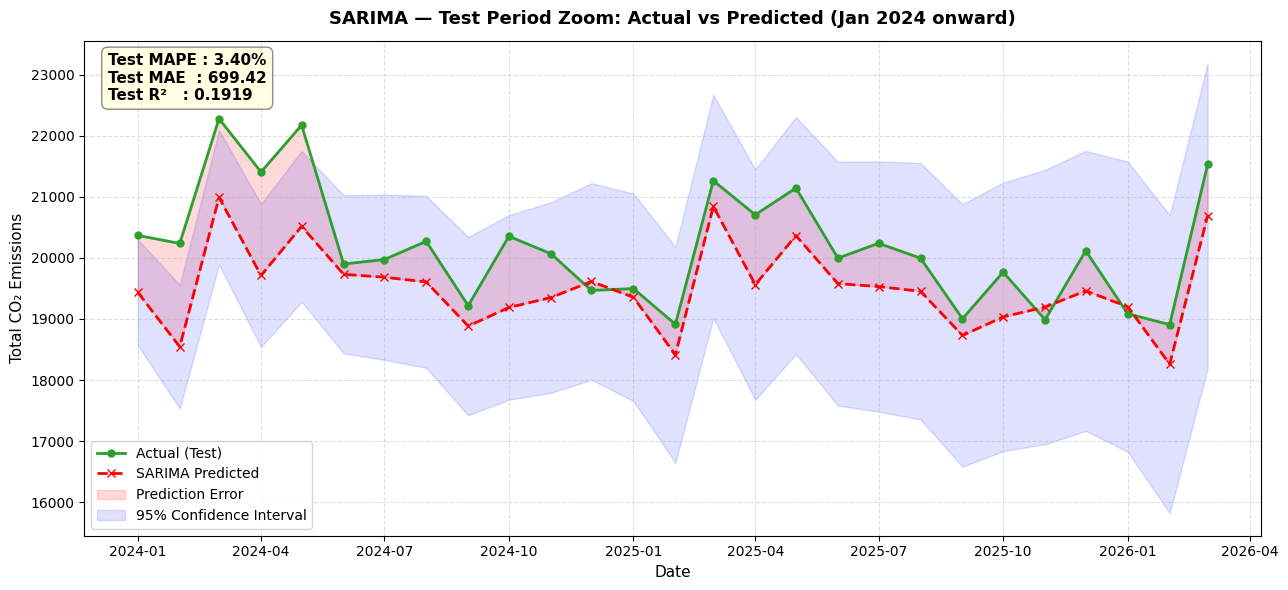

In [ ]:
# ============================================================
# ZOOMED TEST PERIOD — Actual vs Predicted
# ============================================================

from sklearn.metrics import r2_score

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(test.index, test.values,
        color='#2ca02c', linewidth=2,
        marker='o', markersize=5, label='Actual (Test)')

ax.plot(pred_mean.index, pred_mean.values,
        color='red', linewidth=2,
        linestyle='--', marker='x', markersize=6, label='SARIMA Predicted')

ax.fill_between(test.index, test.values, pred_mean.values,
                alpha=0.15, color='red', label='Prediction Error')

ax.fill_between(pred_ci.index,
                pred_ci.iloc[:, 0], pred_ci.iloc[:, 1],
                alpha=0.12, color='blue', label='95% Confidence Interval')

r2 = r2_score(test.values, pred_mean.values)

ax.annotate(
    f'Test MAPE : {mape:.2f}%\nTest MAE  : {mae:.2f}\nTest R²   : {r2:.4f}',
    xy=(0.02, 0.88), xycoords='axes fraction',
    fontsize=11, fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow',
              edgecolor='gray', alpha=0.9)
)

ax.set_title('SARIMA — Test Period Zoom: Actual vs Predicted (Jan 2024 onward)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Total CO₂ Emissions', fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='both', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Metric                       In-Sample   Out-Sample
MAE                             344.97       699.42
MAPE (%)                          2.75         3.40
R²                              0.9916       0.1919
MAPE Gap                          0.65%


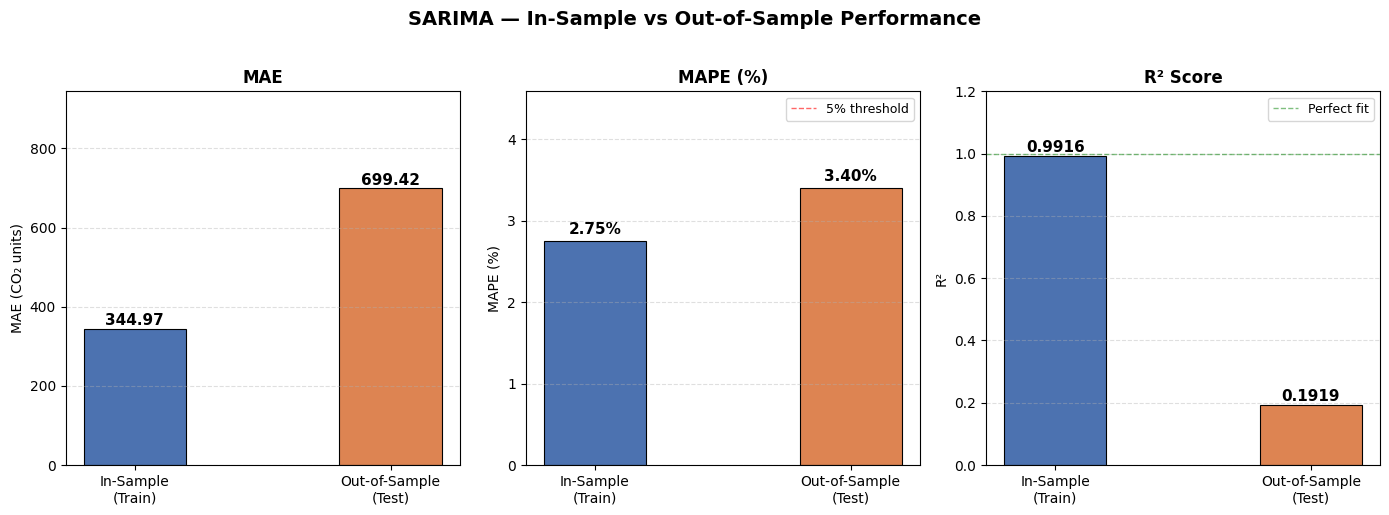

In [ ]:
# ============================================================
# BAR CHART — Train vs Test Metrics (MAE, MAPE, R²)
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# In-sample (train) predictions
train_pred = result.predict(start=train.index[0], end=train.index[-1])

# Compute train metrics
train_mae  = mean_absolute_error(train.values, train_pred.values)
train_mape = np.mean(np.abs((train.values - train_pred.values) / train.values)) * 100
train_r2   = r2_score(train.values, train_pred.values)

# Test metrics (already computed above, recalculate r2 for consistency)
test_mae  = mean_absolute_error(test.values, pred_mean.values)
test_mape = np.mean(np.abs((test.values - pred_mean.values) / test.values)) * 100
test_r2   = r2_score(test.values, pred_mean.values)

print('=' * 52)
print(f"{'Metric':<25} {'In-Sample':>12} {'Out-Sample':>12}")
print('=' * 52)
print(f"{'MAE':<25} {train_mae:>12.2f} {test_mae:>12.2f}")
print(f"{'MAPE (%)':<25} {train_mape:>12.2f} {test_mape:>12.2f}")
print(f"{'R²':<25} {train_r2:>12.4f} {test_r2:>12.4f}")
print('=' * 52)
print(f"{'MAPE Gap':<25} {test_mape - train_mape:>12.2f}%")

# ── Bar Charts ──────────────────────────────────────────────
labels = ['In-Sample\n(Train)', 'Out-of-Sample\n(Test)']
colors = ['#4C72B0', '#DD8452']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('SARIMA — In-Sample vs Out-of-Sample Performance',
             fontsize=14, fontweight='bold', y=1.02)

# --- MAE ---
vals_mae = [train_mae, test_mae]
bars1 = axes[0].bar(labels, vals_mae, color=colors, width=0.4,
                    edgecolor='black', linewidth=0.8)
for bar, val in zip(bars1, vals_mae):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 1,
                 f'{val:.2f}', ha='center', va='bottom',
                 fontsize=11, fontweight='bold')
axes[0].set_title('MAE', fontsize=12, fontweight='bold')
axes[0].set_ylabel('MAE (CO₂ units)', fontsize=10)
axes[0].set_ylim(0, max(vals_mae) * 1.35)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# --- MAPE ---
vals_mape = [train_mape, test_mape]
bars2 = axes[1].bar(labels, vals_mape, color=colors, width=0.4,
                    edgecolor='black', linewidth=0.8)
for bar, val in zip(bars2, vals_mape):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.05,
                 f'{val:.2f}%', ha='center', va='bottom',
                 fontsize=11, fontweight='bold')
axes[1].set_title('MAPE (%)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('MAPE (%)', fontsize=10)
axes[1].set_ylim(0, max(vals_mape) * 1.35)
axes[1].axhline(y=5, color='red', linestyle='--', linewidth=1,
                alpha=0.6, label='5% threshold')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

# --- R² ---
vals_r2 = [train_r2, test_r2]
bars3 = axes[2].bar(labels, vals_r2, color=colors, width=0.4,
                    edgecolor='black', linewidth=0.8)
for bar, val in zip(bars3, vals_r2):
    axes[2].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', va='bottom',
                 fontsize=11, fontweight='bold')
axes[2].set_title('R² Score', fontsize=12, fontweight='bold')
axes[2].set_ylabel('R²', fontsize=10)
axes[2].set_ylim(0, 1.2)
axes[2].axhline(y=1.0, color='green', linestyle='--', linewidth=1,
                alpha=0.5, label='Perfect fit')
axes[2].legend(fontsize=9)
axes[2].grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()